# Week 5 — Data Quality & Sanity Checks

**Goal:** Validate the consistency of the demand dataset (turnstile counts) before expanding visualizations and KPIs.

This notebook will:
- Count **null values** per column
- Detect **duplicates** by `station + date`
- Flag **negative** passengers and **outliers** (configurable percentile per line)
- Export **anomaly CSV** → `../data/processed/quality_flags.csv`
- Generate a **boxplot** of passenger distribution by line → `../assets/screenshots/week5_quality.png`

In [1]:
# === Week 5 — Fast Loader with Best-Read Scoring + Semicolon Unpack (single cell) ===
from pathlib import Path
from collections import Counter
import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import warnings

# ----------------- Configuration -----------------
DATA_DIR = Path("../data/raw/molinetes")
OUTPUT_DIR = Path("../data/processed")
OUTPUT_FLAGS = OUTPUT_DIR / "quality_flags.csv"
SCREENSHOTS_DIR = Path("../assets/screenshots")
SCREENSHOT_PATH = SCREENSHOTS_DIR / "week5_quality.png"

DATE_COL = "date"
STATION_COL = "station"
LINE_COL = "line"
PASSENGERS_COL = "passengers"

FILTER_FROM = pd.Timestamp("2024-01-01")
FILTER_TO   = pd.Timestamp("2024-12-31 23:59:59")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SCREENSHOTS_DIR.mkdir(parents=True, exist_ok=True)

print("Reading CSVs from:", DATA_DIR.resolve())
print("Anomalies export:", OUTPUT_FLAGS.resolve())
print("Expected screenshot:", SCREENSHOT_PATH.resolve())

warnings.filterwarnings(
    "ignore",
    message="Could not infer format, so each element will be parsed individually"
)

# ----------------- Helpers -----------------
def norm(s: str) -> str:
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^a-z0-9_]", "", s)
    return s

def score_read(df, sep_used):
    """
    Mayor score = estructura más útil.
    - favorece >=6 columnas
    - favorece headers “fecha/desde/hasta/linea/estacion/…”
    - penaliza si hay ';' embebido en muchas celdas (señal de empaquetado)
    """
    if df is None or df.shape[1] == 0:
        return -999
    cols_norm = [norm(c) for c in df.columns]
    cols_set = set(cols_norm)
    score = 0
    # columnas esperables (antes de normalizar downstream)
    expected = {"fecha","desde","hasta","linea","molinete","estacion",
                "pax_pagos","pax_pases_pagos","pax_franq","pax_total"}
    score += 2 * len(expected & cols_set)
    # tamaño razonable
    if 6 <= len(cols_norm) <= 30: score += 3
    if sep_used == ";": score += 2  # sesgo a ';' por evidencia
    # penalización por empaquetado (mucha presencia de ';' adentro)
    sample = df.head(200) if len(df) > 200 else df
    packed_hits = 0
    total_cells = 0
    for c in sample.columns:
        s = sample[c].astype(str)
        total_cells += s.size
        packed_hits += int(s.str.contains(";").sum())
    ratio = packed_hits / max(total_cells,1)
    if ratio > 0.10:  # >10% de celdas con ';' indica lectura mala
        score -= 5
    return score

def try_read_best(file):
    """
    Prueba combinaciones (encoding, sep, header=0) y devuelve la de mejor score.
    Si ninguna es útil, devuelve None.
    """
    encodings = ["utf-8-sig", "utf-8", "latin1"]
    # Probamos primero ';' (por evidencia) y luego infer/otros
    seps = [";", None, ",", "\t", "|"]
    best = (-999, None, None)  # (score, df, meta)

    for enc in encodings:
        for sep in seps:
            try:
                df = pd.read_csv(
                    file, engine="python", sep=sep if sep is not None else None,
                    encoding=enc, on_bad_lines="skip", low_memory=True
                )
                if df.shape[0] == 0 or df.shape[1] == 0:
                    continue
                sc = score_read(df, sep or "infer")
                if sc > best[0]:
                    best = (sc, df, {"encoding": enc, "sep": sep if sep is not None else "infer", "header": 0})
            except Exception:
                continue
    return best[1], best[2]

def unpack_semicolon_if_needed(df):
    """
    Si detecta una columna con ';' en >=70% de filas, la desempaqueta en:
    fecha;desde;hasta;linea;molinete;estacion;pax_pagos;pax_pases_pagos;pax_franq;pax_total
    Devuelve (df_posiblemente_modificado, did_unpack: bool)
    """
    if df is None or df.shape[1] == 0:
        return df, False

    n = len(df)
    if n == 0:
        return df, False

    # 1) Encontrar la columna "empaquetada"
    threshold = int(0.7 * n)
    target_col = None
    for c in df.columns:
        cnt = int(df[c].astype(str).str.contains(";").sum())
        if cnt >= threshold:
            target_col = c
            break
    if target_col is None:
        return df, False

    # 2) Split por ';'
    pieces = df[target_col].astype(str).str.split(";", expand=True)
    if pieces.shape[1] < 6:
        # No parece ser el formato esperado, no tocamos
        return df, False

    # 3) Armar nuevas columnas esperadas (hasta donde alcance)
    expected = ["fecha","desde","hasta","linea","molinete","estacion",
                "pax_pagos","pax_pases_pagos","pax_franq","pax_total"]
    new_cols = {expected[i]: pieces[i] for i in range(min(len(expected), pieces.shape[1]))}

    # 4) Quitar la columna empaquetada y también cualquier columna que choque por nombre
    rest = df.drop(columns=[target_col], errors="ignore").copy()
    rest = rest.drop(columns=[c for c in expected if c in rest.columns], errors="ignore")

    # 5) Concat y **deduplicar** nombres conservando la última aparición (la desempaquetada)
    df2 = pd.concat([rest, pd.DataFrame(new_cols)], axis=1)
    df2 = df2.loc[:, ~df2.columns.duplicated(keep="last")]

    # 6) Limpiar comillas/espacios en las columnas nuevas (ya son Series, no DataFrame)
    for c in new_cols.keys():
        if c in df2.columns:
            s = df2[c].astype(str).str.strip()
            s = s.str.replace(r'^"|"$', "", regex=True)
            df2[c] = s

    # 7) Si la primera fila parece un header embebido, descartarla
    head_tokens = "|".join([str(v).lower() for v in df2.head(1).values.flatten().tolist()])
    if any(tok in head_tokens for tok in ["fecha","linea","estacion","pax_total","pax_pagos"]):
        # Heurística: solo dropear si esa "fila-header" no tiene números en pax_pagos/pax_total
        # (para evitar borrar una fila válida)
        drop_first = True
        for cand in ("pax_total","pax_pagos"):
            if cand in df2.columns:
                vals = pd.to_numeric(pd.Series([df2.iloc[0][cand]]), errors="coerce")
                if vals.notna().any():
                    drop_first = False
                    break
        if drop_first:
            df2 = df2.iloc[1:].reset_index(drop=True)

    return df2, True

def pick_col(cols, candidates, prefer_regex=None):
    for cand in candidates:
        if cand in cols:
            return cand
    if prefer_regex:
        rgx = re.compile(prefer_regex)
        for c in cols:
            if rgx.search(c):
                return c
    return None

# --- PATCH: build_date that prefers FECHA + DESDE (preserve 15-min) ---
def build_date(df):
    """
    Prefer exact datetime at 15-min resolution when both 'fecha' (date) and 'desde' (time) exist.
    Fallbacks:
      - 'fecha' already with datetime
      - first token of 'fecha' (if contains ';')
      - Y/M/D components
    Returns (Series[datetime64[ns]], info dict) or (None, info)
    """
    cols = set(df.columns)

    def _clean_str(s):
        return s.astype(str).str.strip().str.replace(r'^"|"$', "", regex=True)

    # 1) FECHA + DESDE → '%d/%m/%Y %H:%M:%S' (or '%H:%M')
    if "fecha" in cols and "desde" in cols:
        f = _clean_str(df["fecha"])
        d = _clean_str(df["desde"])
        # If 'fecha' still includes packed content like 'dd/mm/YYYY;HH:MM:SS;...', take first token
        f = f.str.split(";", n=1, expand=True)[0]
        # Normalize time (if missing seconds, add ':00')
        d = d.str.split(";", n=1, expand=True)[0]
        d = d.where(~d.str.fullmatch(r"\d{1,2}:\d{2}"), d + ":00")
        combo = (f + " " + d).str.strip()

        p = pd.to_datetime(combo, errors="coerce", dayfirst=True)
        if p.notna().any():
            return p, {"mode": "fecha+desde", "source": "fecha,desde", "fmt": "dd/mm/YYYY HH:MM:SS"}

    # 2) Single 'fecha' as datetime
    if "fecha" in cols:
        f = _clean_str(df["fecha"])
        # if packed, take first token
        f0 = f.str.split(";", n=1, expand=True)[0]
        p = pd.to_datetime(f0, errors="coerce", dayfirst=True)
        if p.notna().any():
            return p, {"mode": "single", "source": "fecha", "fmt": "infer(dayfirst=True)"}

    # 3) Generic single date-like columns often seen
    for cand in ["fecha_hora","fechahora","timestamp","datetime","date","period","periodo","fh"]:
        if cand in cols:
            s = _clean_str(df[cand]).str.split(";", n=1, expand=True)[0]
            p = pd.to_datetime(s, errors="coerce", dayfirst=True)
            if p.notna().any():
                return p, {"mode": "single", "source": cand, "fmt": "infer(dayfirst=True)"}

    # 4) Y/M/D components
    y_opts, m_opts, d_opts = ["anio","ano","año","year","yyyy"], ["mes","month","mm","mes_num"], ["dia","día","day","dd"]
    def pick(opts):
        for o in opts:
            if o in cols: return o
        return None
    y = pick(y_opts); m = pick(m_opts); d = pick(d_opts)
    if y and m and d:
        years  = pd.to_numeric(df[y], errors="coerce")
        months = pd.to_numeric(df[m], errors="coerce")
        days   = pd.to_numeric(df[d], errors="coerce")
        p = pd.to_datetime({"year": years, "month": months, "day": days}, errors="coerce")
        if p.notna().any():
            return p, {"mode": "ymd", "source": f"{y}/{m}/{d}", "fmt": None}

    return None, {"mode":"none","source":None,"fmt":None}

def choose_passengers_col(df):
    pref = [
        "pasajeros", "passengers", "pax_pagos", "ingresos", "validaciones",
        "entries", "viajes", "cantidad", "total", "conteo", "count", "pax_total"
    ]
    for p in pref:
        if p in df.columns:
            return p
    hint = re.compile(r"(pax|pasaj|ingres|valid|viaj|cant|total|conte|count)")
    numeric_like = [c for c in df.columns if hint.search(c)]
    if numeric_like:
        # Elegimos la que tenga más numéricos parseables
        best, best_score = None, -1
        for c in numeric_like:
            vals = pd.to_numeric(df[c], errors="coerce")
            score = int(vals.notna().sum())
            if score > best_score:
                best, best_score = c, score
        return best
    return None

# ----------------- Main Load Loop -----------------
all_files = sorted(DATA_DIR.glob("*.csv"))
print(f"Found {len(all_files)} CSV files in {DATA_DIR}")

loaded_frames, skipped = [], []
schema_counter = Counter()
mapping_log = []

for file in all_files:
    # 1) Mejor lectura
    raw, meta = try_read_best(file)
    if raw is None:
        skipped.append((file.name, "read_fail"))
        continue

    # 2) Normalizamos headers
    raw.columns = [norm(c) for c in raw.columns]
    schema_counter.update([tuple(sorted(raw.columns))])

    # 3) Si detectamos empaquetado por ';', desempaquetamos
    raw_unpacked, did_unpack = unpack_semicolon_if_needed(raw)
    if did_unpack:
        raw = raw_unpacked
        raw.columns = [norm(c) for c in raw.columns]

    # 4) Mapeo tolerante
    cols = set(raw.columns)
    station_col = pick_col(cols, ["station","estacion","estacion_nombre","station_name"], prefer_regex=r"(estacion|station|boca)")
    line_col    = pick_col(cols, ["line","linea","linea_id","linea_nombre"],       prefer_regex=r"(linea|line)")
    passengers_col = choose_passengers_col(raw)
    date_series, date_info = build_date(raw)

    # 5) Validación
    if station_col is None or line_col is None or date_series is None or passengers_col is None:
        missing_parts = []
        if date_series is None:   missing_parts.append("date")
        if station_col is None:   missing_parts.append("station")
        if line_col is None:      missing_parts.append("line")
        if passengers_col is None:missing_parts.append("passengers")
        skipped.append((file.name, "unmappable:" + ",".join(missing_parts)))
        continue

    sub = pd.DataFrame({
        DATE_COL: date_series,
        STATION_COL: raw[station_col],
        LINE_COL: raw[line_col],
        PASSENGERS_COL: pd.to_numeric(raw[passengers_col], errors="coerce")
    })

    mapping_log.append((file.name, {
        "encoding": meta["encoding"], "sep": meta["sep"], "header": meta.get("header", 0),
        "unpacked": did_unpack,
        "date": date_info, "station": station_col, "line": line_col, "passengers": passengers_col
    }))
    loaded_frames.append(sub)

# ----------------- Post -----------------
if not loaded_frames:
    print("\nNo CSV loaded. Schema variants seen:")
    for schema, cnt in schema_counter.most_common(10):
        print(f"  {cnt} files → {schema}")
    print("\nExamples of skip reasons (first 10):")
    for name, reason in skipped[:10]:
        print(" ", name, "→", reason)
    raise RuntimeError("No CSVs could be loaded. Check the schema printouts above.")

df = pd.concat(loaded_frames, ignore_index=True)

# Esenciales + filtro año
before = len(df)
df = df.dropna(subset=[DATE_COL, STATION_COL, LINE_COL])
print(f"Dropped {before - len(df)} rows due to missing date/station/line.")

mask_year = (df[DATE_COL] >= FILTER_FROM) & (df[DATE_COL] <= FILTER_TO)
kept = int(mask_year.sum())
print(f"Keeping rows in 2024 range: {kept}/{len(df)}")
df = df.loc[mask_year].copy()

# dtypes
df[STATION_COL] = df[STATION_COL].astype("category")
df[LINE_COL] = df[LINE_COL].astype("category")
df[PASSENGERS_COL] = df[PASSENGERS_COL].astype("Float64")

# Report
print("\nLoaded files:", len(loaded_frames))
print("Final shape:", df.shape)
print("Rows with invalid dates (NaT):", int(df[DATE_COL].isna().sum()))

print("\nSample mapping log (first 8 files):")
for name, m in mapping_log[:8]:
    hdr = m.get("header", 0)
    print(f" - {name}: enc={m['encoding']}, sep={m['sep']}, header={hdr}, unpacked={m['unpacked']}, date={m['date']}, station={m['station']}, line={m['line']}, passengers={m['passengers']}")

if skipped:
    print(f"\nSkipped files: {len(skipped)}")
    for name, reason in skipped[:10]:
        print("  -", name, "→", reason)
    if len(skipped) > 10:
        print(f"  ... and {len(skipped)-10} more")

display(df.head(5))


Reading CSVs from: C:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard\data\raw\molinetes
Anomalies export: C:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard\data\processed\quality_flags.csv
Expected screenshot: C:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard\assets\screenshots\week5_quality.png
Found 24 CSV files in ..\data\raw\molinetes
Dropped 0 rows due to missing date/station/line.
Keeping rows in 2024 range: 11440440/11440440

Loaded files: 24
Final shape: (11440440, 4)
Rows with invalid dates (NaT): 0

Sample mapping log (first 8 files):
 - 202401_PAX15min-ABC.csv: enc=utf-8, sep=infer, header=0, unpacked=True, date={'mode': 'fecha+desde', 'source': 'fecha,desde', 'fmt': 'dd/mm/YYYY HH:MM:SS'}, station=estacion, line=linea, passengers=pax_pagos
 - 202401_PAX15min-DEH.csv: enc=utf-8, sep=infer, header=0, unpacked=True, date={'mode': 'fecha+desde', 'source': 'fecha,desde', 'fmt': 'dd/mm/YYYY HH:MM:

,date,station,line,passengers
0,2024-01-01 07:45:00,Malabia,LineaB,3.0
1,2024-01-01 07:45:00,Tronador,LineaB,1.0
2,2024-01-01 07:45:00,Carlos Pellegrini,LineaB,13.0
3,2024-01-01 07:45:00,Flores,LineaA,2.0
4,2024-01-01 07:45:00,Dorrego,LineaB,1.0


In [2]:
# --- Block 2: Quick dataset profile ---
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Date range:", df["date"].min(), "→", df["date"].max())
print("Lines:", list(df["line"].cat.categories))
print("Stations (unique):", df["station"].nunique())

# Memory footprint (approx)
mem_mb = df.memory_usage(deep=True).sum() / (1024**2)
print(f"Estimated memory usage: {mem_mb:.1f} MB")

Shape: (11440440, 4)
Columns: ['date', 'station', 'line', 'passengers']
Date range: 2024-01-01 07:45:00 → 2024-12-31 22:00:00
Lines: ['LineaA', 'LineaB', 'LineaC', 'LineaD', 'LineaE', 'LineaH']
Stations (unique): 97
Estimated memory usage: 294.6 MB


In [3]:
# --- Block 3: Build data-quality flags (nulls, outliers, duplicates) ---

# Ensure passengers is numeric
df["passengers"] = pd.to_numeric(df["passengers"], errors="coerce").astype("Float64")

# Null flags
flag_null_pass = df["passengers"].isna()

# Negative or impossible values
flag_negative = df["passengers"] < 0

# Per-line extreme outliers (upper-tail)
# We compute a robust high threshold per line (99.9th percentile).
hi_q = df.groupby("line")["passengers"].quantile(0.999).rename("p999")
df = df.merge(hi_q, on="line", how="left")
flag_extreme = df["passengers"] > df["p999"]

# Duplicates (exact timestamp): station + line + date
dup_mask = df.duplicated(subset=["station", "line", "date"], keep=False)

# Compose anomaly rows
any_flag = flag_null_pass | flag_negative | flag_extreme | dup_mask
anomalies = df.loc[any_flag, ["date", "station", "line", "passengers"]].copy()
anomalies["flag_null_passengers"] = flag_null_pass.loc[any_flag].values
anomalies["flag_negative"] = flag_negative.loc[any_flag].values
anomalies["flag_extreme"] = flag_extreme.loc[any_flag].values
anomalies["flag_duplicate_key"] = dup_mask.loc[any_flag].values

# Human-readable reason
reasons = []
for n, neg, ext, dup in zip(
    anomalies["flag_null_passengers"],
    anomalies["flag_negative"],
    anomalies["flag_extreme"],
    anomalies["flag_duplicate_key"],
):
    r = []
    if n:   r.append("null_passengers")
    if neg: r.append("negative_value")
    if ext: r.append("extreme_outlier_line")
    if dup: r.append("duplicate_station_line_date")
    reasons.append("|".join(r))
anomalies["reason"] = reasons

# Quick summary
print("Anomaly counts by reason:")
print(anomalies["reason"].value_counts().head(20))

# Clean up helper column
df.drop(columns=["p999"], inplace=True, errors="ignore")


C:\Users\do_ch\AppData\Local\Temp\ipykernel_16900\4007487257.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hi_q = df.groupby("line")["passengers"].quantile(0.999).rename("p999")


Anomaly counts by reason:
reason
duplicate_station_line_date                         11343625
extreme_outlier_line|duplicate_station_line_date       11144
extreme_outlier_line                                      39
Name: count, dtype: int64


In [4]:
# --- Block 4: Export anomalies to /data/processed/quality_flags.csv ---
OUTPUT_FLAGS.parent.mkdir(parents=True, exist_ok=True)
anomalies_sorted = anomalies.sort_values(["line", "station", "date"]).reset_index(drop=True)
anomalies_sorted.to_csv(OUTPUT_FLAGS, index=False, encoding="utf-8")
print(f"Saved anomalies → {OUTPUT_FLAGS.resolve()}")
print("Rows exported:", len(anomalies_sorted))


Saved anomalies → C:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard\data\processed\quality_flags.csv
Rows exported: 11354808


C:\Users\do_ch\AppData\Local\Temp\ipykernel_16900\2034948578.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cap = df.groupby("line")["passengers"].quantile(0.995).to_dict()


<Figure size 1200x720 with 0 Axes>

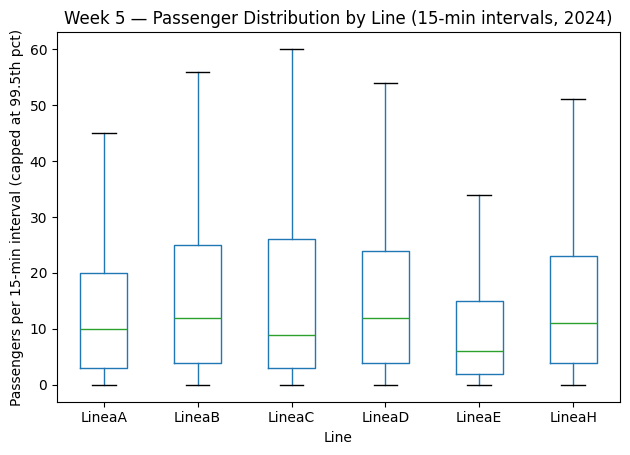

Saved chart → C:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard\assets\screenshots\week5_quality.png


In [5]:
# --- Block 5: Distribution plot by line (boxplot) + save PNG ---
import matplotlib.pyplot as plt

# For a more readable boxplot, cap extreme values at each line's 99.5th percentile
cap = df.groupby("line")["passengers"].quantile(0.995).to_dict()
df_plot = df.copy()
df_plot["passengers_capped"] = df_plot.apply(
    lambda r: min(r["passengers"], cap.get(r["line"], r["passengers"])) if pd.notna(r["passengers"]) else r["passengers"],
    axis=1
)

plt.figure(figsize=(10, 6), dpi=120)
# Sort lines alphabetically for deterministic order
order = sorted(df_plot["line"].cat.categories.tolist())
bp = df_plot.boxplot(
    column="passengers_capped",
    by="line",
    showfliers=False,
    grid=False
)
plt.title("Week 5 — Passenger Distribution by Line (15-min intervals, 2024)")
plt.suptitle("")  # remove pandas automatic suptitle
plt.xlabel("Line")
plt.ylabel("Passengers per 15-min interval (capped at 99.5th pct)")
plt.tight_layout()

SCREENSHOTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(SCREENSHOT_PATH, bbox_inches="tight")
plt.show()

print(f"Saved chart → {SCREENSHOT_PATH.resolve()}")


In [ ]:
# --- Block 6: Build a clean dataset (dedupe + outliers recompute) ---

print("Before clean — rows:", len(df))
print("Datetime sample:", df["date"].iloc[0], "dtype:", df["date"].dtype)

# 1) Ensure proper dtypes
df["passengers"] = pd.to_numeric(df["passengers"], errors="coerce").astype("Float64")
df["line"] = df["line"].astype("category")
df["station"] = df["station"].astype("category")

# 2) Exact-duplicate check at 15-min resolution
dup_mask = df.duplicated(subset=["station", "line", "date"], keep=False)
dups_count = int(dup_mask.sum())
print("Remaining exact duplicates (station,line,date):", dups_count)

# 3) Aggregate duplicates by SUM (best practice for counters)
if dups_count > 0:
    df_clean = (
        df.groupby(["station","line","date"], observed=True, as_index=False)["passengers"]
          .sum()  # sum counts across duplicates
    )
else:
    df_clean = df.copy()

# 4) Recompute outliers on clean data (line-level, upper tail)
p995 = df_clean.groupby("line", observed=True)["passengers"].quantile(0.995).rename("p995")
p999 = df_clean.groupby("line", observed=True)["passengers"].quantile(0.999).rename("p999")

df_clean = df_clean.merge(p995, on="line", how="left").merge(p999, on="line", how="left")
df_clean["flag_extreme_p995"] = df_clean["passengers"] > df_clean["p995"]
df_clean["flag_extreme_p999"] = df_clean["passengers"] > df_clean["p999"]

print("\nClean dataset shape:", df_clean.shape)
print("Extreme > p99.5:", int(df_clean["flag_extreme_p995"].sum()))
print("Extreme > p99.9:", int(df_clean["flag_extreme_p999"].sum()))

# 5) Save optimized formats (fast to load later)
CLEAN_PARQUET = OUTPUT_DIR / "molinetes_2024_clean.parquet"
CLEAN_CSV     = OUTPUT_DIR / "molinetes_2024_clean.csv"

df_clean_out = df_clean.drop(columns=["p995","p999"])  # flags stay
df_clean_out.to_parquet(CLEAN_PARQUET, index=False)
df_clean_out.to_csv(CLEAN_CSV, index=False, encoding="utf-8")

print(f"\nSaved clean parquet → {CLEAN_PARQUET.resolve()}")
print(f"Saved clean csv     → {CLEAN_CSV.resolve()}")

# 6) Quick sanity: ensure 15-min cadence exists (optional)
# sample_line = df_clean[df_clean["line"] == df_clean["line"].cat.categories[0]]
# dt_diff = sample_line.sort_values("date")["date"].diff().dropna()
# print("Sample cadence (top 5 deltas):", dt_diff.head().tolist())


Before clean — rows: 11440440
Datetime sample: 2024-01-01 07:45:00 dtype: datetime64[ns]
Remaining exact duplicates (station,line,date): 11354769

Clean dataset shape: (2208760, 8)
Extreme > p99.5: 11010
Extreme > p99.9: 2204

Saved clean parquet → C:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard\data\processed\molinetes_2024_clean.parquet
Saved clean csv     → C:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard\data\processed\molinetes_2024_clean.csv


In [ ]:
# --- Block 7 (self-contained): Monthly completeness & coverage with auto-located clean dataset ---

import pandas as pd
from pathlib import Path

def find_clean_dataset() -> pd.DataFrame:
    """
    Look for clean parquet/csv under data/processed, walking up to 3 parent dirs.
    Preference: parquet, otherwise csv.
    """
    candidates = []
    cwd = Path.cwd()
    for up in [cwd, cwd.parent, cwd.parent.parent, cwd.parent.parent.parent]:
        base = up / "data" / "processed"
        candidates.append(base / "molinetes_2024_clean.parquet")
        candidates.append(base / "molinetes_2024_clean.csv")

    for p in candidates:
        if p.exists() and p.suffix.lower() == ".parquet":
            print(f"Loading clean dataset (parquet): {p}")
            d = pd.read_parquet(p)
            break
    else:
        for p in candidates:
            if p.exists() and p.suffix.lower() == ".csv":
                print(f"Loading clean dataset (csv): {p}")
                d = pd.read_csv(p)
                break
        else:
            raise FileNotFoundError(
                "Could not find 'molinetes_2024_clean.parquet' or '.csv' under data/processed in ., .., ../.. or ../../.. . "
                "Please run Block 7 to create it (or adjust the search paths here)."
            )

    # standardize dtypes
    d["date"] = pd.to_datetime(d["date"], errors="coerce")
    d["line"] = d["line"].astype("category")
    d["station"] = d["station"].astype("category")
    d["passengers"] = pd.to_numeric(d["passengers"], errors="coerce").astype("Float64")
    return d

# 1) Load clean dataset (auto-locate)
base = find_clean_dataset()
base = base[["date","line","station","passengers"]].copy()

# 2) Monthly coverage vs line-level baseline (p90)
base["year"] = base["date"].dt.year
base["month"] = base["date"].dt.month

monthly_counts = (
    base.groupby(["year","month","line","station"], observed=True)
        .size()
        .rename("n_records")
        .reset_index()
)

monthly_pax = (
    base.groupby(["year","month","line","station"], observed=True)["passengers"]
        .sum(min_count=1)
        .rename("pax_sum")
        .reset_index()
)

qc_month = monthly_counts.merge(monthly_pax, on=["year","month","line","station"], how="left")

line_baseline = (
    qc_month.groupby(["year","month","line"], observed=True)["n_records"]
            .quantile(0.90).rename("baseline_p90")
            .reset_index()
)

qc_month = qc_month.merge(line_baseline, on=["year","month","line"], how="left")
qc_month["coverage_ratio"] = qc_month["n_records"] / qc_month["baseline_p90"]
qc_month["flag_low_coverage"] = qc_month["coverage_ratio"] < 0.80
qc_month["flag_zero_records"] = qc_month["n_records"].fillna(0) == 0

summary = (
    qc_month.groupby(["year","month","line"], observed=True)[["flag_low_coverage","flag_zero_records"]]
            .mean()
            .rename(columns={"flag_low_coverage":"share_low_cov","flag_zero_records":"share_zero"})
            .reset_index()
            .sort_values(["year","month","line"])
)

print("Coverage summary by (year,month,line) — shares are fractions in [0,1]:")
display(summary.head(24))

# Export detailed table
# Save next to the located clean dataset (same discovered base dir)
# Find where we loaded from:
# Recreate path based on successful print above (or just save to nearest data/processed that exists)
save_base = None
for up in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent, Path.cwd().parent.parent.parent]:
    if (up / "data" / "processed").exists():
        save_base = up / "data" / "processed"
        break
if save_base is None:
    save_base = Path.cwd()

QC_COVERAGE_CSV = save_base / "quality_coverage_monthly.csv"
qc_month.sort_values(["year","month","line","station"]).to_csv(QC_COVERAGE_CSV, index=False, encoding="utf-8")
print(f"Saved monthly coverage QC → {QC_COVERAGE_CSV.resolve()}")

# Show a few low-coverage cases
top_low_cov = (
    qc_month[qc_month["flag_low_coverage"]]
    .sort_values("coverage_ratio")
    .head(10)[["year","month","line","station","n_records","baseline_p90","coverage_ratio","pax_sum"]]
)
print("\nSample of low-coverage station-months (top 10):")
display(top_low_cov)


Loading clean dataset (parquet): c:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard\data\processed\molinetes_2024_clean.parquet
Coverage summary by (year,month,line) — shares are fractions in [0,1]:


,year,month,line,share_low_cov,share_zero
0,2024,1,LineaA,0.000000,0.0
1,2024,1,LineaB,0.000000,0.0
2,2024,1,LineaC,0.000000,0.0
3,2024,1,LineaD,0.812500,0.0
4,2024,1,LineaE,0.000000,0.0
5,2024,1,LineaH,0.000000,0.0
6,2024,2,LineaA,0.000000,0.0
7,2024,2,LineaB,0.000000,0.0
8,2024,2,LineaC,0.000000,0.0
9,2024,2,LineaD,0.818182,0.0


Saved monthly coverage QC → C:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard\notebooks\data\processed\quality_coverage_monthly.csv

Sample of low-coverage station-months (top 10):


,year,month,line,station,n_records,baseline_p90,coverage_ratio,pax_sum
225,2024,3,LineaD,Facultad de Medicina,13,1876.0,0.006930,0.0
134,2024,2,LineaD,Bulnes,2,63.0,0.031746,0.0
295,2024,4,LineaB,Pasteur,120,2107.0,0.056953,2495.0
141,2024,2,LineaD,Palermo,5,63.0,0.079365,0.0
142,2024,2,LineaD,Plaza Italia,6,63.0,0.095238,0.0
140,2024,2,LineaD,Olleros,8,63.0,0.126984,8.0
135,2024,2,LineaD,Callao,9,63.0,0.142857,5.0
138,2024,2,LineaD,Juramento,12,63.0,0.190476,2.0
137,2024,2,LineaD,Jose Hernandez,14,63.0,0.222222,0.0
144,2024,2,LineaD,Scalabrini Ortiz,15,63.0,0.238095,1.0


Diagnostics:
  CWD: c:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard\notebooks
  ROOT: c:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard
  CSV used: c:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard\notebooks\data\processed\quality_coverage_monthly.csv
  SCREENSHOTS_DIR: c:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard\assets\screenshots


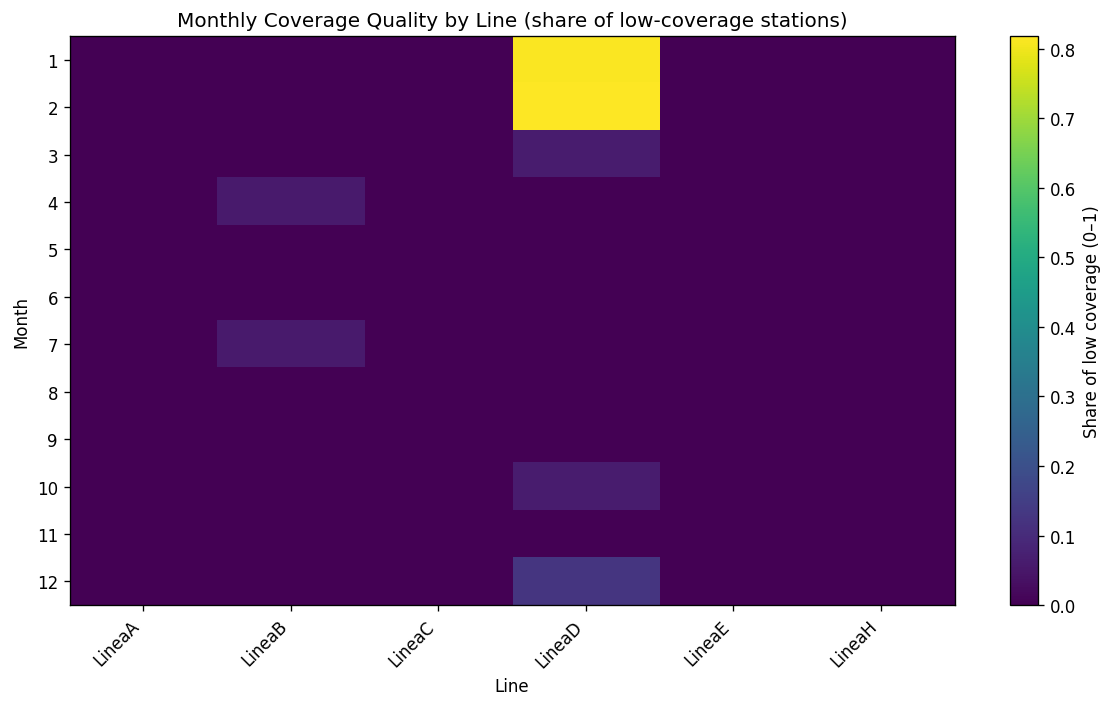

Saved coverage heatmap → C:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard\assets\screenshots\week5_coverage.png


In [ ]:
# Block 8 – Coverage Heatmap (auto-locate CSV + robust save)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def find_repo_root(max_up: int = 6) -> Path:
    cur = Path.cwd()
    best = cur
    best_score = (-1, -1)  # (has_assets+data, has_git)
    for i in range(max_up + 1):
        up = cur if i == 0 else cur.parents[i-1]
        has_assets = (up / "assets").exists()
        has_data   = (up / "data").exists()
        has_git    = (up / ".git").exists()
        score = (int(has_assets and has_data), int(has_git))
        if score > best_score:
            best, best_score = up, score
    return best

def find_coverage_csv() -> Path:
    """
    Busca quality_coverage_monthly.csv en varias rutas (raíz, notebooks/, padres).
    """
    cwd = Path.cwd()
    candidates = []
    for up in [cwd, cwd.parent, cwd.parent.parent, cwd.parent.parent.parent]:
        candidates.append(up / "data" / "processed" / "quality_coverage_monthly.csv")
        candidates.append(up / "notebooks" / "data" / "processed" / "quality_coverage_monthly.csv")
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "Could not find 'quality_coverage_monthly.csv' in data/processed or notebooks/data/processed.\n"
        "Run Block 8 first (it saves that file), or adjust paths here."
    )

# --- Locate everything ---
CWD  = Path.cwd()
ROOT = find_repo_root()
CSV_PATH = find_coverage_csv()
SCREENSHOTS_DIR = ROOT / "assets" / "screenshots"

print("Diagnostics:")
print("  CWD:", CWD)
print("  ROOT:", ROOT)
print("  CSV used:", CSV_PATH)
print("  SCREENSHOTS_DIR:", SCREENSHOTS_DIR)

df_cov = pd.read_csv(CSV_PATH)

# Build pivot: share of low coverage by (month,line)
if "flag_low_coverage" in df_cov.columns:
    pivot = (
        df_cov.groupby(["month", "line"])["flag_low_coverage"]
        .mean()
        .unstack("line")
        .sort_index()
    )
elif "share_low_cov" in df_cov.columns:
    pivot = (
        df_cov.pivot_table(index="month", columns="line", values="share_low_cov", aggfunc="mean")
        .sort_index()
    )
else:
    raise ValueError("Neither 'flag_low_coverage' nor 'share_low_cov' found in coverage CSV.")

pivot = pivot.reindex(sorted(pivot.columns), axis=1).fillna(0.0)

# --- Plot heatmap (matplotlib only) ---
fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
im = ax.imshow(pivot.to_numpy(), aspect="auto", interpolation="nearest")

ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels([str(int(m)) for m in pivot.index])
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right")

ax.set_title("Monthly Coverage Quality by Line (share of low-coverage stations)")
ax.set_xlabel("Line")
ax.set_ylabel("Month")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Share of low coverage (0–1)")
plt.tight_layout()

# Save PNG (always in repo assets/)
SCREENSHOTS_DIR.mkdir(parents=True, exist_ok=True)
out_path = SCREENSHOTS_DIR / "week5_coverage.png"
plt.savefig(out_path, bbox_inches="tight", dpi=120)
plt.show()

# Confirm and also print a fallback suggestion if needed
if out_path.exists():
    print(f"Saved coverage heatmap → {out_path.resolve()}")
else:
    print("Warning: expected save path not found. Please check write permissions and paths.")


In [ ]:
# --- Block 9: Export worst coverage cases per (line, month) ---

from pathlib import Path

assert "qc_month" in globals(), "Run Block 8 first to create qc_month."

def export_worst_coverage(qc_df: pd.DataFrame, k: int = 10, path: Path = None) -> pd.DataFrame:
    """
    For each (year, month, line), pick the K stations with lowest coverage_ratio.
    """
    # rank within each (year,month,line)
    qc_df = qc_df.copy()
    qc_df["rank_cov"] = qc_df.groupby(["year","month","line"], observed=True)["coverage_ratio"].rank(method="first", ascending=True)
    worst = qc_df.sort_values(["year","month","line","coverage_ratio"]).groupby(["year","month","line"], observed=True).head(k)

    if path is not None:
        worst.to_csv(path, index=False, encoding="utf-8")
        print(f"Saved worst coverage cases → {path.resolve()}")
    return worst

# Save next to quality_coverage_monthly.csv if possible
save_dir = None
for up in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent, Path.cwd().parent.parent.parent]:
    if (up / "data" / "processed").exists():
        save_dir = up / "data" / "processed"
        break
if save_dir is None:
    save_dir = Path.cwd()

WORST_CSV = save_dir / "quality_coverage_worst_cases.csv"
worst_cases = export_worst_coverage(qc_month, k=10, path=WORST_CSV)

print("Worst coverage sample:")
display(worst_cases.head(20)[["year","month","line","station","n_records","baseline_p90","coverage_ratio","pax_sum"]])


Saved worst coverage cases → C:\Users\do_ch\OneDrive\Escritorio\Proyectos\Proyectos GitHub\subte-dashboard\notebooks\data\processed\quality_coverage_worst_cases.csv
Worst coverage sample:


,year,month,line,station,n_records,baseline_p90,coverage_ratio,pax_sum
8,2024,1,LineaA,Pasco,2081,2183.6,0.953013,49769.0
2,2024,1,LineaA,Carabobo,2132,2183.6,0.976369,158484.0
10,2024,1,LineaA,Piedras,2139,2183.6,0.979575,106802.0
1,2024,1,LineaA,Alberti,2147,2183.6,0.983239,76843.0
3,2024,1,LineaA,Castro Barros,2149,2183.6,0.984155,134038.0
5,2024,1,LineaA,Flores,2149,2183.6,0.984155,188520.0
7,2024,1,LineaA,Loria,2154,2183.6,0.986444,114559.0
16,2024,1,LineaA,Saenz Peña,2154,2183.6,0.986444,122003.0
17,2024,1,LineaA,San Pedrito,2158,2183.6,0.988276,457843.0
9,2024,1,LineaA,Peru,2161,2183.6,0.989650,172277.0
